# DriftGuard : EDA sur la consommation énergétique (PJM)

**Objectif de ce notebook** : comprendre la structure, la qualité et la saisonnalité
des données PJME_hourly avant de construire le pipeline de preprocessing.

Dataset : PJM Hourly Energy Consumption (Kaggle, robikscube)
Fichier utilisé : PJME_hourly.csv

1. Setup & chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("../data/raw/PJME_hourly.csv")
df.head()


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [5]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[us]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.2 MB


In [7]:
print("Shape:", df.shape)
print("Colonnes:", df.columns.tolist())

Shape: (145366, 2)
Colonnes: ['Datetime', 'PJME_MW']


`Datetime` est probablement lu comme une chaîne de caractères (`object`).
On le convertit en vrai type datetime pour pouvoir faire des opérations temporelles.

In [8]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[us]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.2 MB


2. Qualité des données
## Qualité des données

On vérifie ici : valeurs manquantes, doublons de timestamp, trous dans la
continuité temporelle, et outliers sur la consommation.

In [9]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
Datetime    0
PJME_MW     0
dtype: int64


In [10]:
# Doublons sur Datetime (peuvent survenir lors du passage heure été/hiver)
n_duplicates = df["Datetime"].duplicated().sum()
print(f"Nombre de timestamps dupliqués : {n_duplicates}")

if n_duplicates > 0:
    display(df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime").head(10))

Nombre de timestamps dupliqués : 4


,Datetime,PJME_MW
112487,2014-11-02 02:00:00,23755.0
112488,2014-11-02 02:00:00,22935.0
121223,2015-11-01 02:00:00,21567.0
121224,2015-11-01 02:00:00,21171.0
130127,2016-11-06 02:00:00,20795.0
130128,2016-11-06 02:00:00,21692.0
138863,2017-11-05 02:00:00,21236.0
138864,2017-11-05 02:00:00,20666.0


In [12]:
# Continuité temporelle : est-ce que chaque heure existe entre min et max ?
full_range = pd.date_range(start=df["Datetime"].min(), end=df["Datetime"].max(), freq="h")
missing_hours = full_range.difference(df["Datetime"])

print(f"Plage attendue : {len(full_range)} heures")
print(f"Plage réelle   : {len(df)} lignes")
print(f"Heures manquantes : {len(missing_hours)}")
missing_hours[:10]  # aperçu des premières heures manquantes

Plage attendue : 145392 heures
Plage réelle   : 145366 lignes
Heures manquantes : 30


DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00'],
              dtype='datetime64[us]', freq=None)

In [13]:
# Outliers sur la consommation
col = "PJME_MW"
print(df[col].describe())

print("\nValeurs <= 0 :", (df[col] <= 0).sum())
print("Valeur min :", df[col].min())
print("Valeur max :", df[col].max())

count    145366.000000
mean      32080.222831
std        6464.012166
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64

Valeurs <= 0 : 0
Valeur min : 14544.0
Valeur max : 62009.0


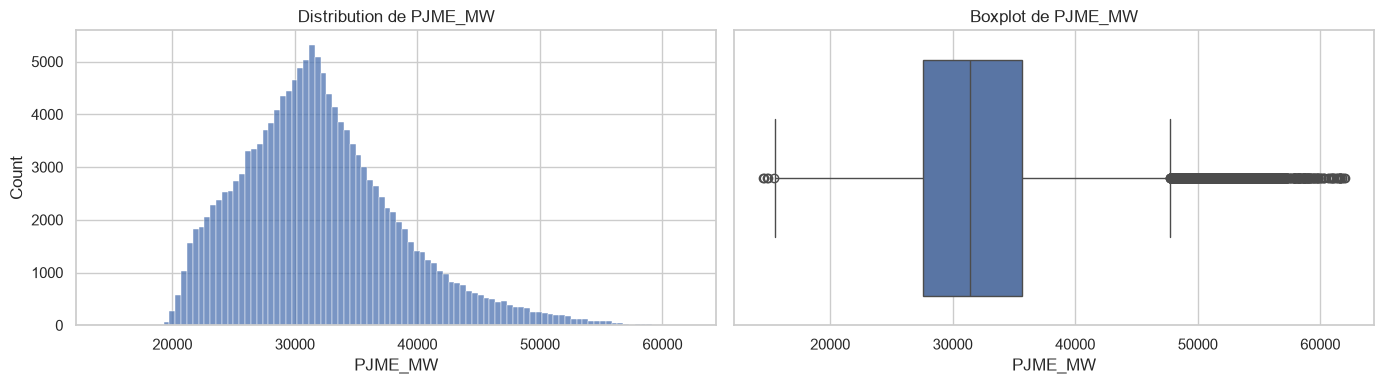

In [14]:
# Visualisation rapide de la distribution pour repérer les outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[col], bins=100, ax=axes[0])
axes[0].set_title("Distribution de PJME_MW")

sns.boxplot(x=df[col], ax=axes[1])
axes[1].set_title("Boxplot de PJME_MW")
plt.tight_layout()
plt.show()

3. Visualisation de la série complète
## Vue d'ensemble de la série temporelle

C'est la visualisation centrale du projet : elle doit montrer la tendance
générale et laisser deviner la saisonnalité à l'œil nu.


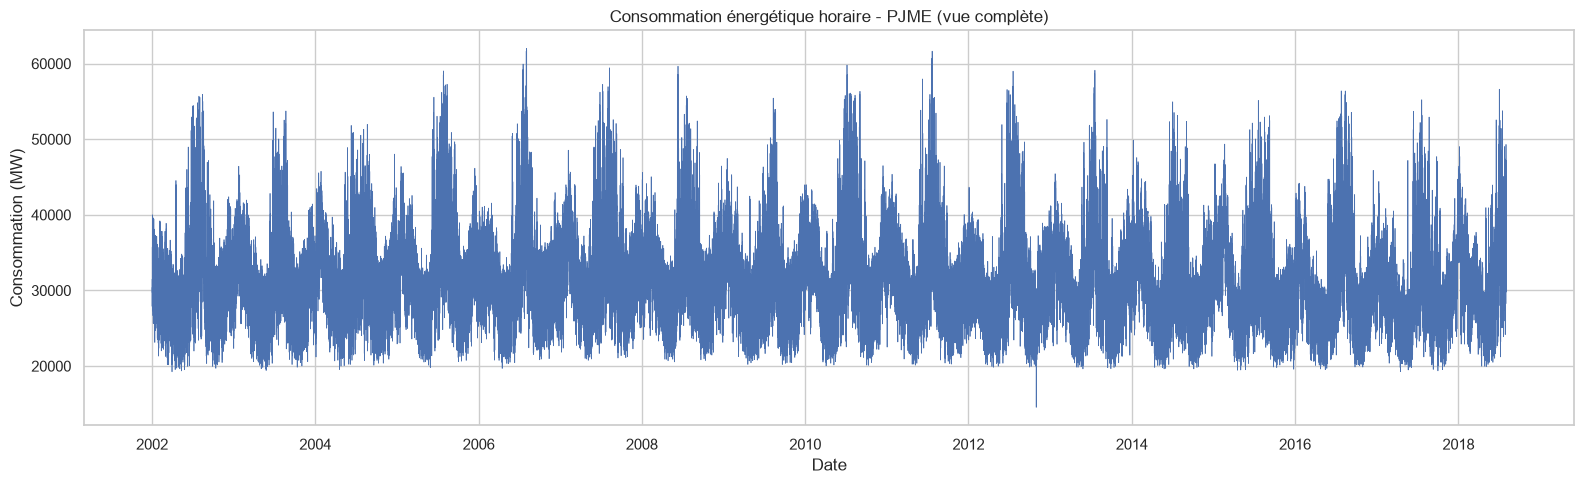

In [17]:
plt.figure(figsize=(16, 5))
plt.plot(df["Datetime"], df[col], linewidth=0.5)
plt.title("Consommation énergétique horaire - PJME (vue complète)")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.tight_layout()
plt.show()

4. Analyse de saisonnalité
## Saisonnalité

On décompose la date en plusieurs granularités (mois, heure, jour de semaine)
pour visualiser où se situe le vrai signal de "drift" saisonnier.

In [18]:
df["year"] = df["Datetime"].dt.year
df["month"] = df["Datetime"].dt.month
df["hour"] = df["Datetime"].dt.hour
df["dayofweek"] = df["Datetime"].dt.dayofweek  # 0 = lundi
df["is_weekend"] = df["dayofweek"].isin([5, 6])

df.head()

,Datetime,PJME_MW,year,month,hour,dayofweek,is_weekend
0,2002-01-01 01:00:00,30393.0,2002,1,1,1,False
1,2002-01-01 02:00:00,29265.0,2002,1,2,1,False
2,2002-01-01 03:00:00,28357.0,2002,1,3,1,False
3,2002-01-01 04:00:00,27899.0,2002,1,4,1,False
4,2002-01-01 05:00:00,28057.0,2002,1,5,1,False


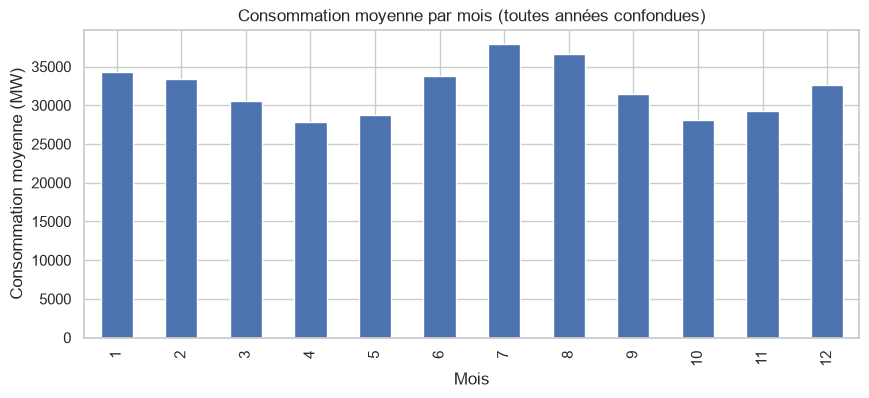

In [19]:
# Moyenne par mois → pattern été/hiver
monthly_avg = df.groupby("month")[col].mean()

plt.figure(figsize=(10, 4))
monthly_avg.plot(kind="bar")
plt.title("Consommation moyenne par mois (toutes années confondues)")
plt.xlabel("Mois")
plt.ylabel("Consommation moyenne (MW)")
plt.show()

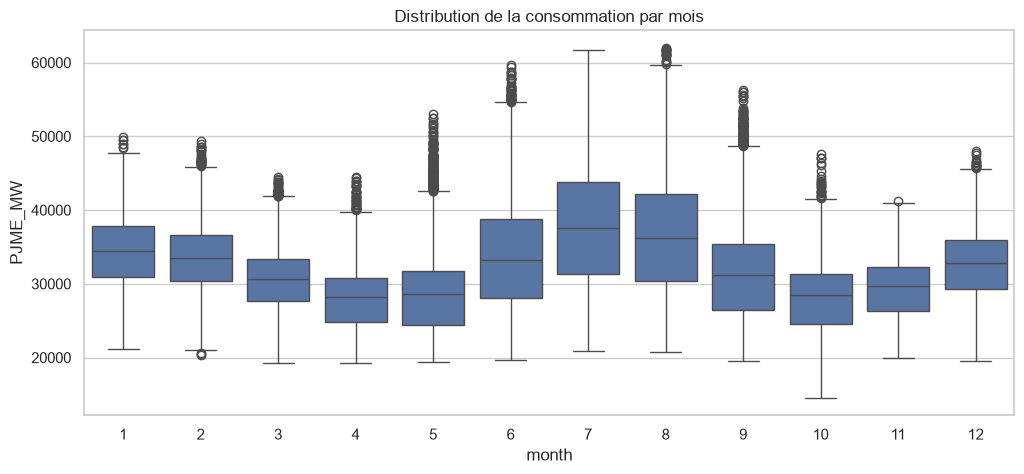

In [20]:
# Boxplot par mois → dispersion en plus de la moyenne
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y=col, data=df)
plt.title("Distribution de la consommation par mois")
plt.show()

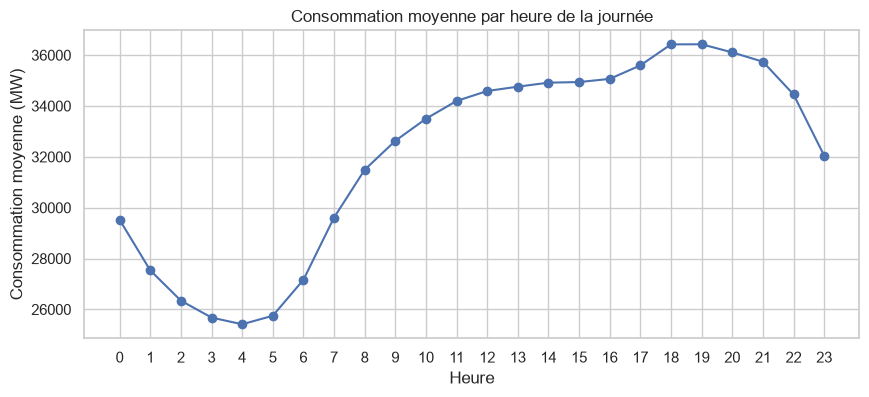

In [21]:
# Moyenne par heure de la journée → pics matin/soir
hourly_avg = df.groupby("hour")[col].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(kind="line", marker="o")
plt.title("Consommation moyenne par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Consommation moyenne (MW)")
plt.xticks(range(0, 24))
plt.show()

is_weekend
False    32996.092730
True     29787.601494
Name: PJME_MW, dtype: float64


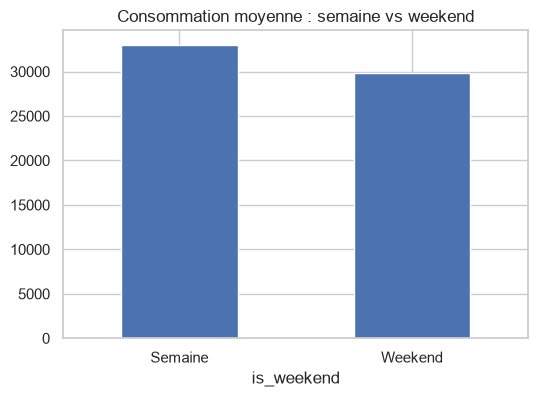

In [22]:
# Weekday vs weekend
weekend_avg = df.groupby("is_weekend")[col].mean()
print(weekend_avg)

plt.figure(figsize=(6, 4))
weekend_avg.plot(kind="bar")
plt.xticks([0, 1], ["Semaine", "Weekend"], rotation=0)
plt.title("Consommation moyenne : semaine vs weekend")
plt.show()

## Décomposition tendance / saisonnalité / résidu

On isole les composantes de la série avec `seasonal_decompose`.
Vu la taille du dataset (16 ans en horaire), on travaille sur un
resample **journalier** pour que la décomposition reste lisible et rapide.

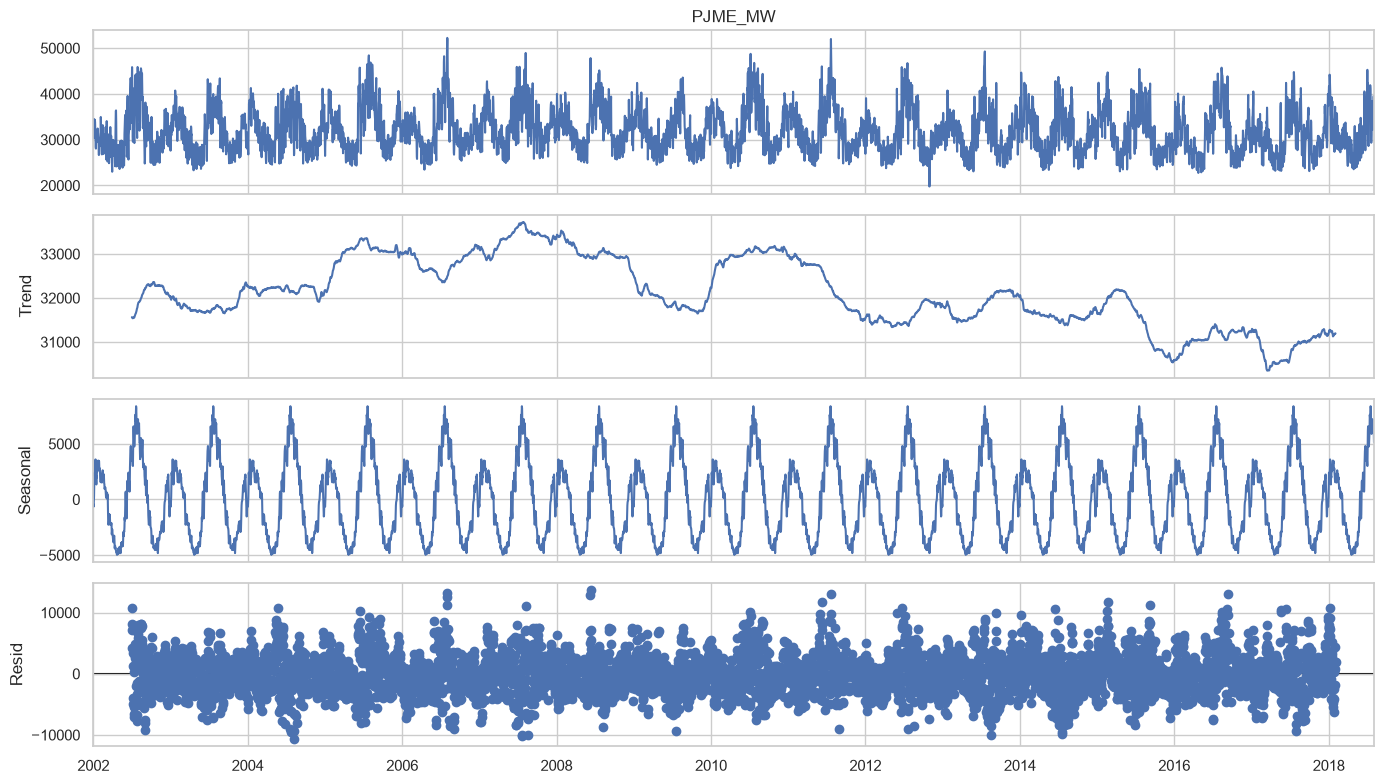

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily = df.set_index("Datetime")[col].resample("D").mean()

decomposition = seasonal_decompose(daily.dropna(), model="additive", period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

## Comparaison de deux périodes — avant-goût du drift

On compare la distribution de la consommation sur deux fenêtres contrastées,
par exemple une année ancienne vs une année récente, pour visualiser
manuellement ce qu'Evidently détectera ensuite automatiquement.

In [25]:
period_reference = df[(df["Datetime"] >= "2005-01-01") & (df["Datetime"] < "2006-01-01")]
period_current = df[(df["Datetime"] >= "2017-01-01") & (df["Datetime"] < "2018-01-01")]

print("Reference (2005):", len(period_reference), "lignes")
print("Current (2017)  :", len(period_current), "lignes")

Reference (2005): 8758 lignes
Current (2017)  : 8760 lignes


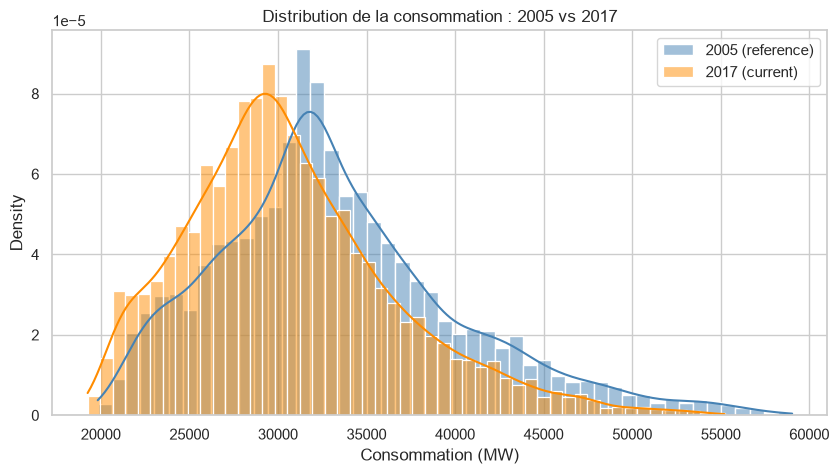

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(period_reference[col], color="steelblue", label="2005 (reference)", 
             stat="density", kde=True, alpha=0.5)
sns.histplot(period_current[col], color="darkorange", label="2017 (current)", 
             stat="density", kde=True, alpha=0.5)
plt.title("Distribution de la consommation : 2005 vs 2017")
plt.xlabel("Consommation (MW)")
plt.legend()
plt.show()

In [27]:
print("Statistiques 2005 :")
print(period_reference[col].describe())
print("\nStatistiques 2017 :")
print(period_current[col].describe())

Statistiques 2005 :
count     8758.000000
mean     33310.478648
std       6917.037149
min      19825.000000
25%      28639.250000
50%      32325.000000
75%      36951.250000
max      59031.000000
Name: PJME_MW, dtype: float64

Statistiques 2017 :
count     8760.000000
mean     30650.911644
std       5992.663514
min      19255.000000
25%      26544.000000
50%      29860.500000
75%      33868.500000
max      55218.000000
Name: PJME_MW, dtype: float64


## Conclusions

- **Valeurs manquantes / trous temporels** : Aucune valeur manquante native
  (0/145366). Cependant, 30 heures sont absentes de la plage temporelle
  attendue, et 4 timestamps sont dupliqués. Les deux phénomènes coïncident
  exactement avec les changements d'heure US (DST) : les heures manquantes
  correspondent au passage à l'heure d'été (perte de l'heure 2h→3h en mars/
  avril), et les doublons au passage à l'heure d'hiver (répétition de 2h en
  novembre). Stratégie retenue pour `preprocessing.py` : dédupliquer avec
  `drop_duplicates(subset="Datetime", keep="first")`, puis réindexer sur une
  plage horaire complète et interpoler les 30 valeurs manquantes
  (interpolation linéaire, vu leur faible nombre et leur caractère isolé).

- **Outliers** : Aucune valeur aberrante détectée. Min = 14544 MW, max =
  62009 MW, aucune valeur nulle ou négative — les extrêmes du boxplot
  correspondent à des pics de consommation réels (probablement vagues de
  chaleur/froid extrêmes), pas à des erreurs de capteur. Aucun traitement
  d'outlier nécessaire à ce stade.

- **Nature du drift observé** : Deux composantes de drift confirmées par la
  décomposition saisonnière :
  1. **Saisonnalité forte et stable** (amplitude ~10000 MW entre pics été/
     hiver et creux printemps/automne), avec un pattern clair en double-bosse
     sur la moyenne mensuelle (pics en juillet-août et janvier-février).
  2. **Tendance de fond à la baisse** depuis 2010 (~33500 MW) jusqu'à 2017
     (~31000 MW), visible sur la composante Trend de la décomposition.
  La comparaison 2005 vs 2017 confirme ce drift de façon mesurable : la
  moyenne passe de 33310 MW à 30651 MW (-8%), avec un écart-type qui diminue
  aussi (6917 → 5993). Le drift est donc à la fois **saisonnier** (cyclique,
  prévisible) et de **tendance long-terme** (structurel).

- **Choix reference / current pour le pipeline** : Reprendre le découpage
  testé dans l'EDA — année 2005 complète comme `reference` (période stable,
  représentative d'un "modèle entraîné sur des données anciennes") et année
  2017 comme `current` (données récentes simulant la production), qui montre
  un drift réel et mesurable sans avoir besoin d'en injecter artificiellement.

- **Features à créer dans le pipeline final** : `month`, `hour`, `dayofweek`
  et `is_weekend` sont tous confirmés comme pertinents — chacun a montré un
  effet visible sur la consommation moyenne (pattern mensuel net, pics
  horaires matin/soir, écart semaine/weekend de ~3200 MW). `year` sera gardé
  pour construire les splits temporels mais ne sera pas utilisé comme feature
  d'entraînement (pour éviter que le modèle "apprenne" une année spécifique).